In [67]:
pip install --user xgboost

Note: you may need to restart the kernel to use updated packages.


In [68]:

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd
import numpy as np
import folium
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder,StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix,f1_score,classification_report
from xgboost import XGBClassifier


In [69]:
Colums=["A1_Score","A2_Score","A3_Score","A4_Score","A5_Score",
        "A6_Score","A7_Score","A8_Score","A9_Score","A10_Score",
        "age","gender","ethicity","jundice","austim","country_of_res",
        "used_app_before","result","age_desc","realation","class/ASD"]
df=pd.read_csv(r"C:\Users\Admin\Downloads\Autism-Adult-Data.csv",names=Colums)
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethicity,jundice,austim,country_of_res,used_app_before,result,age_desc,realation,class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2,'18 and more',?,NO


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   A1_Score         704 non-null    int64 
 1   A2_Score         704 non-null    int64 
 2   A3_Score         704 non-null    int64 
 3   A4_Score         704 non-null    int64 
 4   A5_Score         704 non-null    int64 
 5   A6_Score         704 non-null    int64 
 6   A7_Score         704 non-null    int64 
 7   A8_Score         704 non-null    int64 
 8   A9_Score         704 non-null    int64 
 9   A10_Score        704 non-null    int64 
 10  age              704 non-null    object
 11  gender           704 non-null    object
 12  ethicity         704 non-null    object
 13  jundice          704 non-null    object
 14  austim           704 non-null    object
 15  country_of_res   704 non-null    object
 16  used_app_before  704 non-null    object
 17  result           704 non-null    in

In [71]:
df.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,result
count,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000
mean,0.721591,0.453125,0.457386,0.495739,0.498580,0.284091,0.417614,0.649148,0.323864,0.573864,4.875000
std,0.448535,0.498152,0.498535,0.500337,0.500353,0.451301,0.493516,0.477576,0.468281,0.494866,2.501493
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,4.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000


In [72]:
df=df.drop(["A1_Score","A2_Score","A3_Score","A4_Score","A5_Score","A6_Score","A7_Score","A8_Score","A9_Score","A10_Score","age_desc","used_app_before"],axis=1)	
df.head()

,age,gender,ethicity,jundice,austim,country_of_res,result,realation,class/ASD
0,26,f,White-European,no,no,'United States',6,Self,NO
1,24,m,Latino,no,yes,Brazil,5,Self,NO
2,27,m,Latino,yes,yes,Spain,8,Parent,YES
3,35,f,White-European,no,yes,'United States',6,Self,NO
4,40,f,?,no,no,Egypt,2,?,NO


In [73]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)
df

,age,gender,ethicity,jundice,austim,country_of_res,result,realation,class/ASD
0,26,f,White-European,no,no,'United States',6,Self,NO
1,24,m,Latino,no,yes,Brazil,5,Self,NO
2,27,m,Latino,yes,yes,Spain,8,Parent,YES
3,35,f,White-European,no,yes,'United States',6,Self,NO
4,40,f,?,no,no,Egypt,2,?,NO
...,...,...,...,...,...,...,...,...,...
658,25,f,White-European,no,no,Russia,7,Self,YES
659,34,m,Hispanic,no,no,Mexico,3,Parent,NO
660,24,f,?,no,no,Russia,7,?,YES
661,35,m,'South Asian',no,no,Pakistan,6,Self,NO


In [74]:
df.isnull().sum()

age               0
gender            0
ethicity          0
jundice           0
austim            0
country_of_res    0
result            0
realation         0
class/ASD         0
dtype: int64

In [75]:
import numpy as np


df.replace('?', np.nan, inplace=True)
df

,age,gender,ethicity,jundice,austim,country_of_res,result,realation,class/ASD
0,26,f,White-European,no,no,'United States',6,Self,NO
1,24,m,Latino,no,yes,Brazil,5,Self,NO
2,27,m,Latino,yes,yes,Spain,8,Parent,YES
3,35,f,White-European,no,yes,'United States',6,Self,NO
4,40,f,NaN,no,no,Egypt,2,NaN,NO
...,...,...,...,...,...,...,...,...,...
658,25,f,White-European,no,no,Russia,7,Self,YES
659,34,m,Hispanic,no,no,Mexico,3,Parent,NO
660,24,f,NaN,no,no,Russia,7,NaN,YES
661,35,m,'South Asian',no,no,Pakistan,6,Self,NO


In [76]:
df.isna().sum()

age                2
gender             0
ethicity          88
jundice            0
austim             0
country_of_res     0
result             0
realation         88
class/ASD          0
dtype: int64

In [77]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df=df[df["age"]<80]
df

,age,gender,ethicity,jundice,austim,country_of_res,result,realation,class/ASD
0,26.0,f,White-European,no,no,'United States',6,Self,NO
1,24.0,m,Latino,no,yes,Brazil,5,Self,NO
2,27.0,m,Latino,yes,yes,Spain,8,Parent,YES
3,35.0,f,White-European,no,yes,'United States',6,Self,NO
4,40.0,f,NaN,no,no,Egypt,2,NaN,NO
...,...,...,...,...,...,...,...,...,...
658,25.0,f,White-European,no,no,Russia,7,Self,YES
659,34.0,m,Hispanic,no,no,Mexico,3,Parent,NO
660,24.0,f,NaN,no,no,Russia,7,NaN,YES
661,35.0,m,'South Asian',no,no,Pakistan,6,Self,NO


In [78]:
df["realation"]=df["realation"].fillna(df["realation"].mode()[0])
df["ethicity"]=df["ethicity"].fillna(df["ethicity"].mode()[0])
df

C:\Users\Admin\AppData\Local\Temp\ipykernel_26656\1976095724.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Admin\AppData\Local\Temp\ipykernel_26656\1976095724.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,age,gender,ethicity,jundice,austim,country_of_res,result,realation,class/ASD
0,26.0,f,White-European,no,no,'United States',6,Self,NO
1,24.0,m,Latino,no,yes,Brazil,5,Self,NO
2,27.0,m,Latino,yes,yes,Spain,8,Parent,YES
3,35.0,f,White-European,no,yes,'United States',6,Self,NO
4,40.0,f,White-European,no,no,Egypt,2,Self,NO
...,...,...,...,...,...,...,...,...,...
658,25.0,f,White-European,no,no,Russia,7,Self,YES
659,34.0,m,Hispanic,no,no,Mexico,3,Parent,NO
660,24.0,f,White-European,no,no,Russia,7,Self,YES
661,35.0,m,'South Asian',no,no,Pakistan,6,Self,NO


In [79]:
df.isnull().sum()

age               0
gender            0
ethicity          0
jundice           0
austim            0
country_of_res    0
result            0
realation         0
class/ASD         0
dtype: int64

In [80]:
df["country_of_res"] = df["country_of_res"].astype(str).str.lower().str.replace("'", "", regex=False).str.strip()
df["ethicity"] = df["ethicity"].astype(str).str.lower().str.replace("'", "", regex=False).str.strip()
df

C:\Users\Admin\AppData\Local\Temp\ipykernel_26656\3011029431.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Admin\AppData\Local\Temp\ipykernel_26656\3011029431.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,age,gender,ethicity,jundice,austim,country_of_res,result,realation,class/ASD
0,26.0,f,white-european,no,no,united states,6,Self,NO
1,24.0,m,latino,no,yes,brazil,5,Self,NO
2,27.0,m,latino,yes,yes,spain,8,Parent,YES
3,35.0,f,white-european,no,yes,united states,6,Self,NO
4,40.0,f,white-european,no,no,egypt,2,Self,NO
...,...,...,...,...,...,...,...,...,...
658,25.0,f,white-european,no,no,russia,7,Self,YES
659,34.0,m,hispanic,no,no,mexico,3,Parent,NO
660,24.0,f,white-european,no,no,russia,7,Self,YES
661,35.0,m,south asian,no,no,pakistan,6,Self,NO


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 660 entries, 0 to 662
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             660 non-null    float64
 1   gender          660 non-null    object 
 2   ethicity        660 non-null    object 
 3   jundice         660 non-null    object 
 4   austim          660 non-null    object 
 5   country_of_res  660 non-null    object 
 6   result          660 non-null    int64  
 7   realation       660 non-null    object 
 8   class/ASD       660 non-null    object 
dtypes: float64(1), int64(1), object(7)
memory usage: 51.6+ KB


In [82]:
df.isnull().sum()

age               0
gender            0
ethicity          0
jundice           0
austim            0
country_of_res    0
result            0
realation         0
class/ASD         0
dtype: int64

In [83]:
df.describe()

,age,result
count,660.000000,660.000000
mean,29.428788,4.927273
std,9.806137,2.523489
min,17.000000,0.000000
25%,22.000000,3.000000
50%,27.000000,4.000000
75%,35.000000,7.000000
max,64.000000,10.000000


In [84]:
df 


,age,gender,ethicity,jundice,austim,country_of_res,result,realation,class/ASD
0,26.0,f,white-european,no,no,united states,6,Self,NO
1,24.0,m,latino,no,yes,brazil,5,Self,NO
2,27.0,m,latino,yes,yes,spain,8,Parent,YES
3,35.0,f,white-european,no,yes,united states,6,Self,NO
4,40.0,f,white-european,no,no,egypt,2,Self,NO
...,...,...,...,...,...,...,...,...,...
658,25.0,f,white-european,no,no,russia,7,Self,YES
659,34.0,m,hispanic,no,no,mexico,3,Parent,NO
660,24.0,f,white-european,no,no,russia,7,Self,YES
661,35.0,m,south asian,no,no,pakistan,6,Self,NO


which age affect the austim?

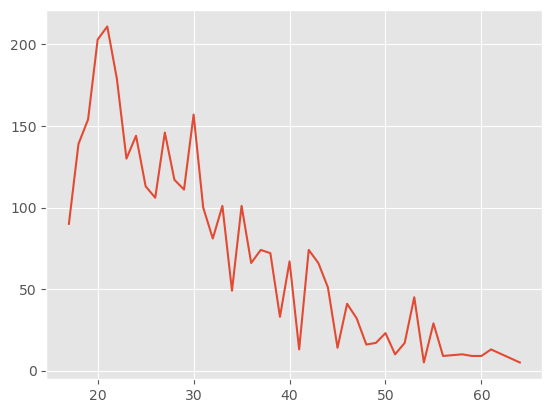

In [85]:
groups=df.groupby("age")["result"].sum()
plt.plot(groups.index,groups.values);

the age between 17 to 30 

the highest country effect autsm and thier ages?

In [86]:
fig = px.bar(df, x='country_of_res', y='result',color="age")
fig.show()

united states and their age between 17 to 30

In [87]:
fig = px.violin(df, x='realation', y='austim',color="age",
                box=True, title='realation of austim')
fig.show()

In [88]:
fig = px.bar(df, x='realation', y='jundice',color="age",
             barmode='stack', title='ethicity  by austim')
fig.show()

In [89]:
fig = px.bar(df, x='ethicity', y='austim',color="age",
             barmode='stack', title='ethicity  by austim')
fig.show()

which heighest ethicity has jundice

In [90]:
fig = px.bar(df, x='ethicity', y='jundice',color="age",
             barmode='stack', title='ethicity  by jundice')
fig.show()

white-european heighest jundice

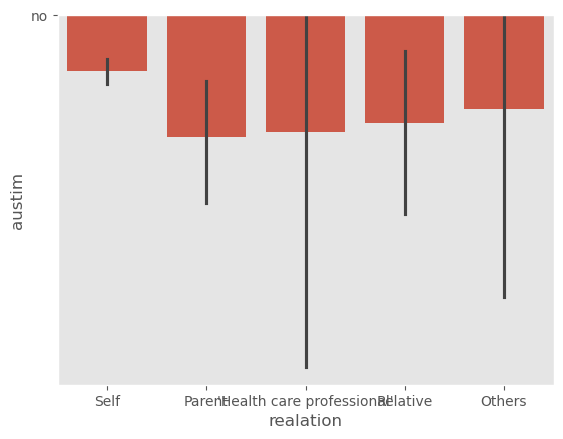

In [91]:
sns.barplot(x="realation",y="austim",data=df);

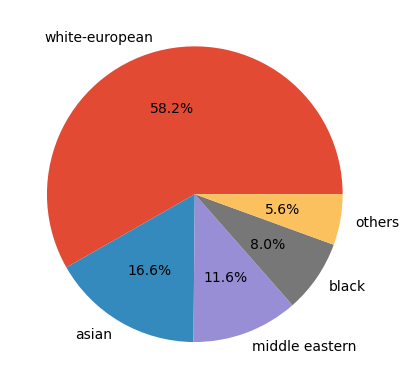

In [92]:
top_ethicity = df.groupby('ethicity')['result'].sum()
top_ethicity=top_ethicity.sort_values(ascending=False)
top_ethicity=top_ethicity.head(5)
plt.style.use("ggplot")
plt.pie(top_ethicity.values, labels=top_ethicity.index, autopct='%1.1f%%');

<Axes: xlabel='class/ASD', ylabel='count'>

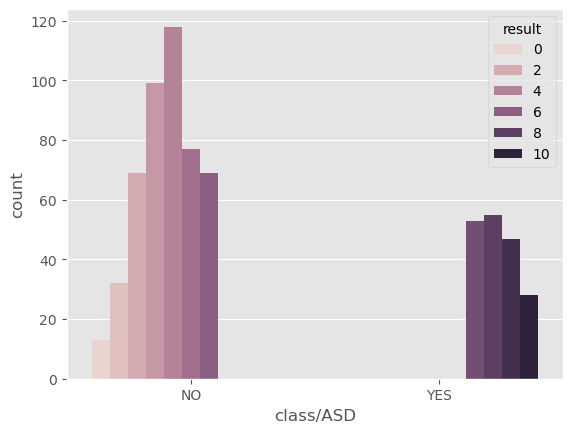

In [93]:
sns.countplot(x='class/ASD', hue='result', data=df)

<Axes: xlabel='jundice', ylabel='count'>

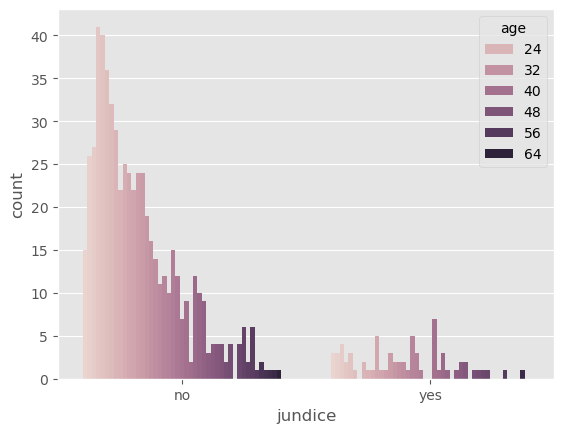

In [94]:
sns.countplot(x='jundice', hue='age', data=df)

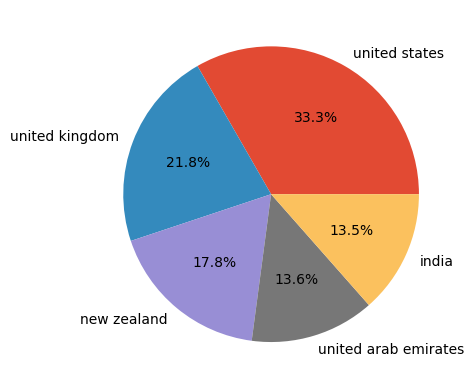

In [95]:
top_country_of_res = df.groupby('country_of_res')['result'].sum()
top_country_of_res=top_country_of_res.sort_values(ascending=False)
top_country_of_res=top_country_of_res.head(5)
plt.style.use("ggplot")
plt.pie(top_country_of_res.values, labels=top_country_of_res.index, autopct='%1.1f%%');

which realation highest affect in class/asd?

<Axes: xlabel='realation', ylabel='count'>

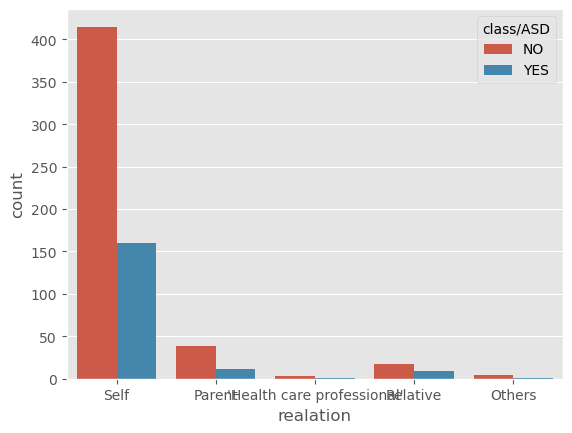

In [96]:
sns.countplot(data=df,x="realation",hue='class/ASD')

parent most effect in class/asd

which gender affect austim?

<Axes: xlabel='gender', ylabel='count'>

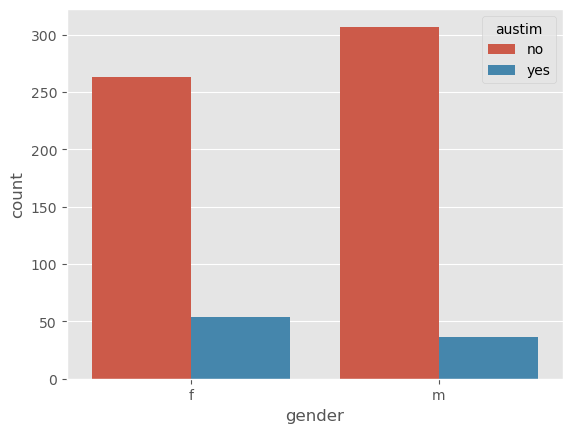

In [97]:
sns.countplot(data=df,x="gender",hue='austim')

famale affect austim

In [98]:
#m =folium.Map(location=(30.044 , 31.2357),zoom_start=6)
#Iraqi_loc=[33.3333 , 44.4333]
#united_states_loc=[37.843322, -105.948203 ]
#folium.Marker(Iraqi_loc,popup="Iraqi").add_to(m)
#folium.Marker(united_states_loc,popup="united_states").add_to(m)
#folium.PolyLine([Iraqi_loc,united_states_loc]).add_to(m)
#m

In [99]:
en = LabelEncoder()
df["class/ASD"] = en.fit_transform(df["class/ASD"])
df["class/ASD"]

C:\Users\Admin\AppData\Local\Temp\ipykernel_26656\841730736.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



0      0
1      0
2      1
3      0
4      0
      ..
658    1
659    0
660    1
661    0
662    1
Name: class/ASD, Length: 660, dtype: int64

In [100]:
X = df.drop("class/ASD", axis=1) 
y = df['class/ASD'] 
df

,age,gender,ethicity,jundice,austim,country_of_res,result,realation,class/ASD
0,26.0,f,white-european,no,no,united states,6,Self,0
1,24.0,m,latino,no,yes,brazil,5,Self,0
2,27.0,m,latino,yes,yes,spain,8,Parent,1
3,35.0,f,white-european,no,yes,united states,6,Self,0
4,40.0,f,white-european,no,no,egypt,2,Self,0
...,...,...,...,...,...,...,...,...,...
658,25.0,f,white-european,no,no,russia,7,Self,1
659,34.0,m,hispanic,no,no,mexico,3,Parent,0
660,24.0,f,white-european,no,no,russia,7,Self,1
661,35.0,m,south asian,no,no,pakistan,6,Self,0


In [101]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [102]:
cat_cols = ["gender","ethicity","jundice","austim","country_of_res","realation"]
encoder =  OrdinalEncoder(
 handle_unknown='use_encoded_value',
 unknown_value=-1
)
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

In [103]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)


In [104]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)
y_pred_train = log_model.predict(X_train)
y_pred_test = log_model.predict(X_test)

In [105]:
print(classification_report(y_pred_train,y_train)),
print(classification_report(y_pred_test,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       382
           1       1.00      1.00      1.00       146

    accuracy                           1.00       528
   macro avg       1.00      1.00      1.00       528
weighted avg       1.00      1.00      1.00       528

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        95
           1       1.00      1.00      1.00        37

    accuracy                           1.00       132
   macro avg       1.00      1.00      1.00       132
weighted avg       1.00      1.00      1.00       132



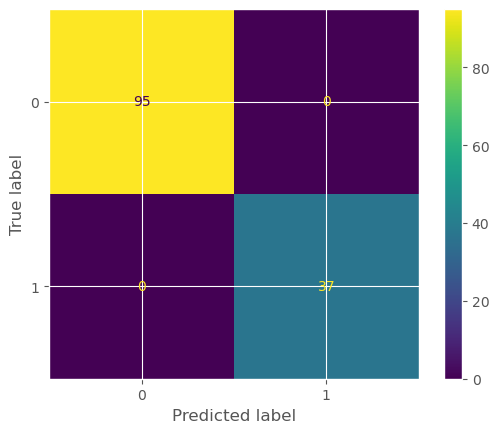

In [106]:
cm=confusion_matrix(y_test,y_pred_test)
ConfusionMatrixDisplay(cm).plot()

In [107]:
dmodel = DecisionTreeClassifier()
dmodel.fit(X_train, y_train)

y_pred_train = dmodel.predict(X_train)
y_pred_test = dmodel.predict(X_test)

In [108]:
print(classification_report(y_pred_train,y_train)),
print(classification_report(y_pred_test,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       382
           1       1.00      1.00      1.00       146

    accuracy                           1.00       528
   macro avg       1.00      1.00      1.00       528
weighted avg       1.00      1.00      1.00       528

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        95
           1       1.00      1.00      1.00        37

    accuracy                           1.00       132
   macro avg       1.00      1.00      1.00       132
weighted avg       1.00      1.00      1.00       132



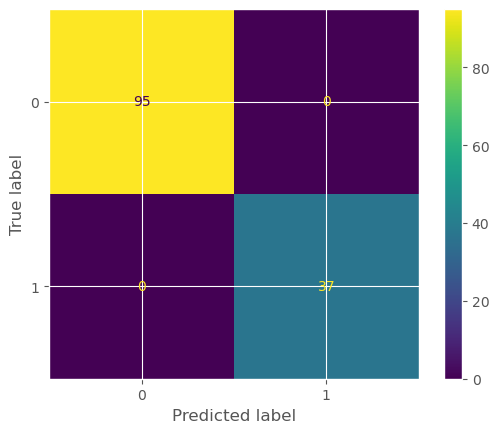

In [109]:
cm=confusion_matrix(y_test,y_pred_test)
ConfusionMatrixDisplay(cm).plot()

In [110]:
rmodel = RandomForestClassifier()
rmodel.fit(X_train, y_train)

y_pred_train = rmodel.predict(X_train)
y_pred_test = rmodel.predict(X_test)

In [111]:
print(classification_report(y_pred_train,y_train)),
print(classification_report(y_pred_test,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       382
           1       1.00      1.00      1.00       146

    accuracy                           1.00       528
   macro avg       1.00      1.00      1.00       528
weighted avg       1.00      1.00      1.00       528

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        95
           1       1.00      1.00      1.00        37

    accuracy                           1.00       132
   macro avg       1.00      1.00      1.00       132
weighted avg       1.00      1.00      1.00       132



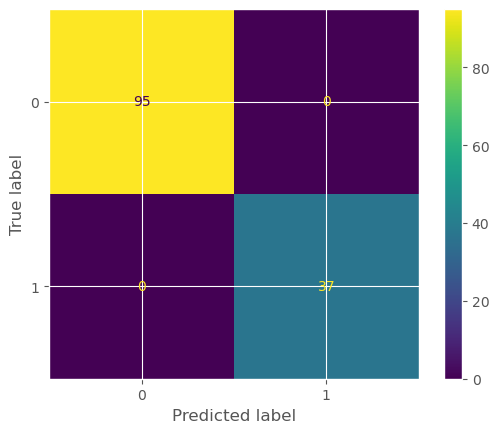

In [112]:
cm=confusion_matrix(y_test,y_pred_test)
ConfusionMatrixDisplay(cm).plot()

In [113]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning:

[19:12:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




In [114]:
print(classification_report(y_pred_train,y_train)),
print(classification_report(y_pred_test,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       382
           1       1.00      1.00      1.00       146

    accuracy                           1.00       528
   macro avg       1.00      1.00      1.00       528
weighted avg       1.00      1.00      1.00       528

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        95
           1       1.00      1.00      1.00        37

    accuracy                           1.00       132
   macro avg       1.00      1.00      1.00       132
weighted avg       1.00      1.00      1.00       132



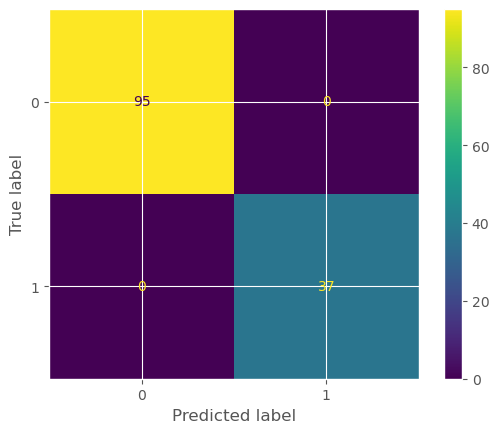

In [115]:
cm=confusion_matrix(y_test,y_pred_test)
ConfusionMatrixDisplay(cm).plot()